# Experimental data

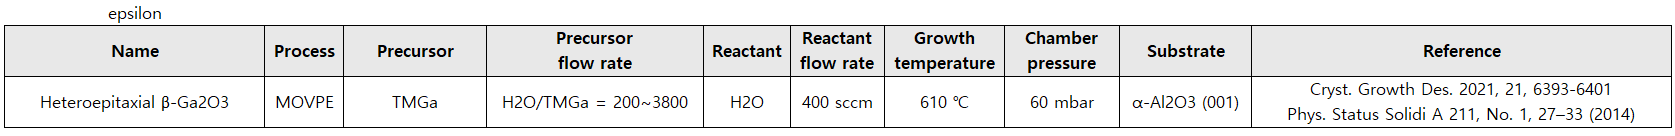

# 1. Calculating relative nucleation rates

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.patches import Wedge


In [3]:
# Physical constants
PI = math.pi
KB = 8.617e-2  # Boltzmann constant, unit: eV/K

def nucleation_rate(surface_meta, n_meta, surface_stable, n_stable, delta_g_rxn, bulk_diff, temp):
    """
    Calculate the nucleation rate
    
    Parameters:
    -----------
    surface_meta : float
        Surface energy of metastable phase (eV/Å²)
    n_meta : float
        Number of atoms per unit volume in metastable phase (atoms/Å³)
    surface_stable : float
        Surface energy of stable phase (eV/Å²)
    n_stable : float
        Number of atoms per unit volume in stable phase (atoms/Å³)
    delta_g_rxn : float
        Reaction free energy change (eV/atom)
    bulk_diff : float
        Bulk energy difference (eV/atom)
    temp : float
        Temperature (K)
    
    Returns:
    --------
    rate : float
        Calculated nucleation rate
    """
    try:
        # First term
        term1 = surface_meta**3 / (n_meta**2 * (delta_g_rxn + bulk_diff)**2)
        
        # Second term
        term2 = surface_stable**3 / (n_stable**2 * delta_g_rxn**2)
        
        # Constant coefficient in exponent
        constant = (16 * PI) / (3 * KB * temp)
        
        # Exponent
        exponent = constant * (term1 - term2)
        
        # Nucleation rate
        rate = np.exp(exponent)
        
        return rate
        
    except ZeroDivisionError:
        raise ValueError("Division by zero: n_meta, n_stable, delta_g_rxn, or temp cannot be zero.")
    except Exception as e:
        raise ValueError(f"Unexpected error occurred: {e}")

In [4]:
# Surfaced energy
b_surface = 48 # β-Ga2O3
b_surface_recon = 8 # Reconstruction energy of β-Ga2O3 (J. Mater. Chem. C, 2024, 12, 1820–1832)

e_surface = 71.76 # ε-Ga2O3
e_surface_recon = 27 #J. Mater. Chem. C, 2024, 12, 1820–1832


# Vibrational energy difference
vib_E_diff_e_b = 13

# Strain energy differences
strain_b_e_a_ga2o3 = -5.57 # on α-Ga2O3 substrate

# Interface energy
inter_b_a_Ga2O3 = 47 # Between β-Ga2O3 and α-Ga2O3 (J. Mater. Chem. C, 2025, 13, 1469–1476)
inter_e_a_Ga2O3 = 32 # Between ε-Ga2O3 and α-Ga2O3 (J. Mater. Chem. C, 2025, 13, 1469–1476)

# Density
density_b = 0.09092272200462186
density_b_a_ga2o3 = 0.09355506403533614
density_e = 0.09397063582356113
density_e_a_ga2o3 = 0.09482363798313029


C:\Users\NB\AppData\Local\Temp\ipykernel_3716\3951799056.py:45: RuntimeWarning: overflow encountered in exp
  rate = np.exp(exponent)
C:\Users\NB\AppData\Local\Temp\ipykernel_3716\3486128653.py:17: RuntimeWarning: divide by zero encountered in log
  lnJ_on = np.log(nucleation_rate(
C:\Users\NB\AppData\Local\Temp\ipykernel_3716\3486128653.py:47: RuntimeWarning: divide by zero encountered in log
  lnJ_wo = np.log(nucleation_rate(


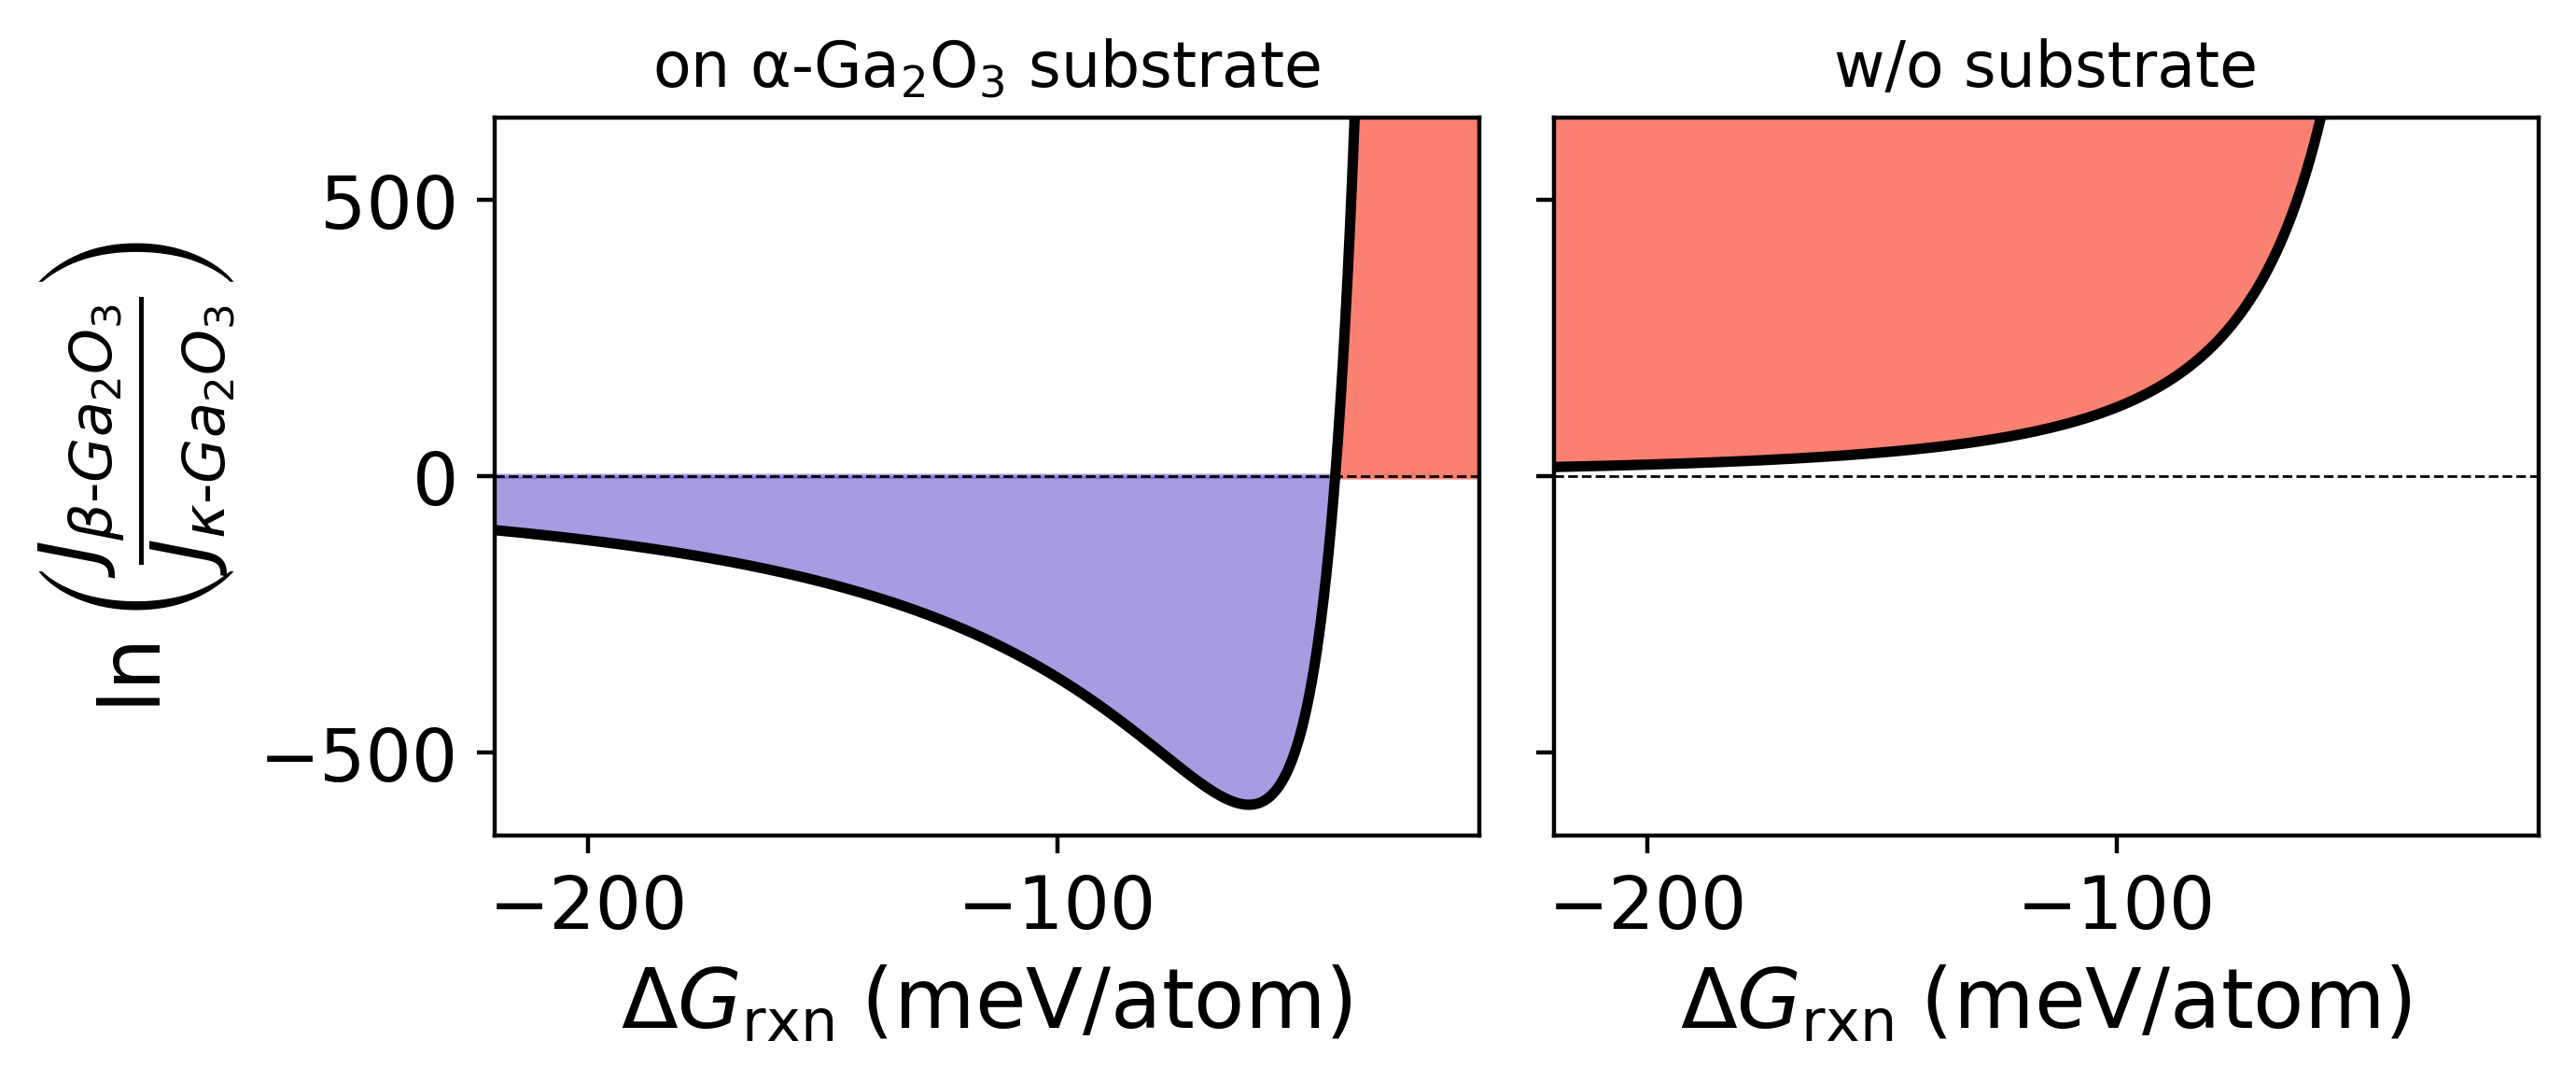

In [5]:
delta_g_rxn = np.arange(-300, 10, 0.01)
plt.figure(figsize=(7, 3), dpi=400)
T = 610 + 273  # K

ymin, ymax = -650, 650
xmin, xmax = -220, -10

lw = 2
ls = 12

# ===================== (1) on α-Ga2O3 =====================
ax1 = plt.subplot(1, 2, 1)
ax1.set_title("on α-Ga$_2$O$_3$ substrate")

ax1.axhline(0, color='k', linestyle='--', linewidth=0.5)

lnJ_on = np.log(nucleation_rate(
    e_surface + inter_e_a_Ga2O3 - e_surface_recon, density_e_a_ga2o3,
    b_surface + inter_b_a_Ga2O3 - b_surface_recon, density_b_a_ga2o3,
    delta_g_rxn,
    strain_b_e_a_ga2o3 + vib_E_diff_e_b,
    T
))

lnJ_on_clipped = np.clip(lnJ_on, ymin, ymax)

ax1.fill_between(delta_g_rxn, 0, lnJ_on_clipped, where=(lnJ_on_clipped < 0), 
                  color="slateblue", interpolate=True,alpha=0.6)

ax1.fill_between(delta_g_rxn, 0, lnJ_on_clipped, where=(lnJ_on_clipped >= 0), 
                  color="salmon", interpolate=True)

mask_finite = np.isfinite(lnJ_on)
ax1.plot(delta_g_rxn[mask_finite], lnJ_on[mask_finite], color="black", linewidth=lw)

ax1.set_ylabel(r"$\ln \left(\dfrac{J_{\beta\text{-}Ga_{2}O_{3}}}{J_{\kappa\text{-}Ga_{2}O_{3}}}\right)$", fontsize=ls+4)
ax1.set_xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV}/\mathrm{atom})$", fontsize=ls+4)
ax1.set_ylim(ymin, ymax)
ax1.set_xlim(xmin, xmax)
ax1.tick_params(labelsize=ls+2)

# ===================== (2) w/o substrate =====================
ax2 = plt.subplot(1, 2, 2)
ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax2.set_title("w/o substrate")

lnJ_wo = np.log(nucleation_rate(
    e_surface - e_surface_recon, density_e,
    b_surface - b_surface_recon, density_b,
    delta_g_rxn,
    vib_E_diff_e_b,
    T
))
ax2.plot(delta_g_rxn, lnJ_wo, linewidth=lw, color="black")

mask_positive_finite = (lnJ_wo >= 0) & np.isfinite(lnJ_wo)
lnJ_wo_for_fill = np.where(mask_positive_finite, lnJ_wo, 0)
ax2.fill_between(delta_g_rxn, lnJ_wo_for_fill, ymax, where=mask_positive_finite, 
                  color="salmon", interpolate=True)

ax2.set_xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV}/\mathrm{atom})$", fontsize=ls+4)
ax2.set_ylim(ymin, ymax)
ax2.set_xlim(xmin, xmax)
ax2.tick_params(labelsize=ls+2)
ax2.tick_params(axis='y', labelleft=False)

plt.tight_layout()

# 2. Reaction pathfindings 

In [6]:
import numpy as np
import collections


from pymatgen.entries.computed_entries import ComputedEntry
from rxn_network.entries.entry_set import GibbsEntrySet
from rxn_network.enumerators.basic import BasicEnumerator
from rxn_network.entries.interpolated import InterpolatedEntry
import pandas as pds


c:\Users\NB\anaconda3\envs\rxn3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-10 11:55:18,435	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [7]:
# =============================================================================
# DFT-calculated Energies
# =============================================================================

# Precursors
TMGa = ComputedEntry("Ga(CH3)3", -62.32542)
DMGa = ComputedEntry("Ga(CH3)2", -40.94100)
MMGa = ComputedEntry("Ga(CH3)", -21.234229)

# Reactants
H2O = ComputedEntry("H2O", -14.233623)

# Target
Ga2O3 = ComputedEntry("Ga2O3", -29.8385)  # beta phase

# By-products
C2H4 = ComputedEntry("C2H4", -31.980520)
CH3 = ComputedEntry("CH3", -18.16748)
C2H5 = ComputedEntry("C2H5", -34.86254)
CH4 = ComputedEntry("CH4", -18.83721)
CO2 = ComputedEntry("C2O4", -22.969825)
H2 = ComputedEntry("H2", -6.7903) 

# Chemical potential of Ga
Ga = ComputedEntry("Ga8", -23.23820)

In [8]:
# =============================================================================
# Physical Constants
# =============================================================================
K_B = 1.380649e-23              # Boltzmann constant (J/K)
EV_PER_J = 1 / 1.60218e-19      # J to eV conversion
MOLAR_VOLUME_STP = 22414        # cm³/mol at STP


# =============================================================================
# Functions
# =============================================================================

def ideal_gas_entry(entry, T, P, P0=1.0):
    """
    Apply ideal gas correction: E_corrected = E + kT*ln(P/P0)
    
    Parameters:
    -----------
    entry : ComputedEntry
    T : float - Temperature (K)
    P : float - Pressure (atm)
    P0 : float - Reference pressure (atm), default=1.0
    
    Returns:
    --------
    ComputedEntry with corrected energy
    """
    kT_J = K_B * T
    correction_J = kT_J * np.log(P / P0)
    correction_eV = correction_J * EV_PER_J
    
    corrected_energy = entry.energy + correction_eV
    return ComputedEntry(entry.composition, corrected_energy)



In [1]:
# =====================
# Conditions
# =====================
temp = 610 + 273  # K

F_He = 400   # sccm
F_H2O = 400 # sccm

F_TMGa_1    = F_H2O / 200
F_TMGa_1_2  = F_H2O / 400
F_TMGa_1_3  =  F_H2O / 600
F_TMGa_1_4  =  F_H2O / 800
F_TMGa_1_5  = F_H2O / 1000
F_TMGa_1_18 = F_H2O / 3800

P_chamber = 60 / 1013.25  # atm


# =====================
# Partial pressure
# =====================
def pp(F_TMGa):
    F_total = F_He + F_H2O + F_TMGa
    y_TMGa = F_TMGa / F_total
    y_H2O  = F_H2O  / F_total
    return y_TMGa * P_chamber, y_H2O * P_chamber

pp_sets = {
    "1":    pp(F_TMGa_1),
    "1_2":  pp(F_TMGa_1_2),
    "1_3":  pp(F_TMGa_1_3),
    "1_4":  pp(F_TMGa_1_4),
    "1_5":  pp(F_TMGa_1_5),
    "1_18": pp(F_TMGa_1_18),
    
}

In [15]:
# =====================
# Loop over conditions
# =====================
all_results = []

# tag and F_TMGa 
flow_map = {
    "1":    round(F_TMGa_1,2),
    "1_2":  round(F_TMGa_1_2,2),
    "1_3":  round(F_TMGa_1_3,2),
    "1_4":  round(F_TMGa_1_4,2),
    "1_5":  round(F_TMGa_1_5,2),
    "1_18": round(F_TMGa_1_18,2),
}

for tag, (pp_precursor, pp_reactant) in pp_sets.items():

    # Ideal gas entries
    ideal_TMGa = ideal_gas_entry(TMGa, temp, pp_precursor)
    ideal_DMGa = ideal_gas_entry(DMGa, temp, pp_precursor)
    ideal_MMGa = ideal_gas_entry(MMGa, temp, pp_precursor)
    ideal_H2O  = ideal_gas_entry(H2O,  temp, pp_reactant)

    TMGa_entries = [
        ideal_TMGa, ideal_DMGa, ideal_MMGa, ideal_H2O,
        Ga2O3, C2H4, CH3, C2H5, CH4, CO2, H2, Ga
    ]

    TMGa_entries_inter = [
        InterpolatedEntry(entry.composition, entry.energy)
        for entry in TMGa_entries
    ]

    TMGa_gibbs_entries = GibbsEntrySet(entries=TMGa_entries_inter)

    be_TMGa = BasicEnumerator(
        n=3,
        precursors=[
            ideal_TMGa.composition,
            ideal_DMGa.composition,
            ideal_MMGa.composition,
            ideal_H2O.composition
        ],
        targets=["Ga2O3"]
    )

    TMGa_rxns = be_TMGa.enumerate(TMGa_gibbs_entries)

    # =====================
    # Collect data
    # =====================
    data = collections.defaultdict(list)

    for rxn in TMGa_rxns:

        data["rxn"].append(rxn)
        data["ΔG_rxn (meV/atom)"].append(round(rxn.energy_per_atom * 1000, 2))
        data["Precursor"].append("TMGa")
        data["Temperature (℃)"].append(temp - 273)
        data["Partial pressure of precursor"].append(pp_precursor)
        data["Partial pressure of reactant"].append(pp_reactant)

        data["Flow of precursor (SCCM)"].append(flow_map[tag])
        data["Flow of reactant (SCCM)"].append(F_H2O)

        for reactant in rxn.reactants:
            if reactant == H2O.composition:
                data["Reactant"].append("H2O")

        by_products = []
        for product in rxn.products:
            if product != Ga2O3.composition:
                by_products.append(product.reduced_formula)

        data["By-products"].append(', '.join(str(p) for p in by_products))

    df = pds.DataFrame(
        data,
        columns=[
            "Precursor",
            "Flow of precursor (SCCM)",
            "Partial pressure of precursor",
            "Reactant",
            "Flow of reactant (SCCM)",
            "Partial pressure of reactant",
            "Temperature (℃)",
            "By-products",
            "ΔG_rxn (meV/atom)",
            "rxn"
        ]
    )

    df = df.sort_values("ΔG_rxn (meV/atom)")
    df.insert(0, "Reaction", range(1, len(df) + 1))

    case_label_map = {
        "1":    "F_TMGa",
        "1_2":  "F_TMGa/2",
        "1_3":  "F_TMGa/3",
        "1_4":  "F_TMGa/4",
        "1_5":  "F_TMGa/5",
        "1_18": "F_TMGa/18",
    }

    df["Case"] = case_label_map[tag]
    all_results.append(df)

Building chunks...: 100%|██████████| 9/9 [00:00<00:00, 529.50it/s]


Enumerating reactions (BasicEnumerator): 100%|██████████| 6/6 [00:00<00:00, 27.11it/s]


In [16]:
# =====================
# Merge & print
# =====================
df_all = pds.concat(all_results, ignore_index=True)
df_all = df_all.sort_values("ΔG_rxn (meV/atom)")

In [20]:
# df_all.to_excel("rnxs_kappa_flow_rate.xlsx")

In [17]:
df_all

,Reaction,Precursor,Flow of precursor (SCCM),Partial pressure of precursor,Reactant,Flow of reactant (SCCM),Partial pressure of reactant,Temperature (℃),By-products,ΔG_rxn (meV/atom),rxn,Case
0,1,TMGa,2.00,0.000148,H2O,400,0.029534,610,"Ga(H3C)3, H2",-166.04,3 GaH3C + 3 H2O -> Ga2O3 + Ga(H3C)3 + 3 H2,F_TMGa
21,1,TMGa,1.00,0.000074,H2O,400,0.029571,610,"H2, Ga(H3C)3",-161.66,H2O + GaH3C -> H2 + 0.3333 Ga2O3 + 0.3333 Ga(H...,F_TMGa/2
42,1,TMGa,0.67,0.000049,H2O,400,0.029583,610,"H2, Ga(H3C)3",-159.10,GaH3C + H2O -> H2 + 0.3333 Ga(H3C)3 + 0.3333 G...,F_TMGa/3
63,1,TMGa,0.50,0.000037,H2O,400,0.029589,610,"Ga(H3C)3, H2",-157.28,3 GaH3C + 3 H2O -> Ga2O3 + Ga(H3C)3 + 3 H2,F_TMGa/4
84,1,TMGa,0.40,0.000030,H2O,400,0.029593,610,"H2, Ga(H3C)3",-155.86,3 H2O + 3 GaH3C -> Ga2O3 + 3 H2 + Ga(H3C)3,F_TMGa/5
...,...,...,...,...,...,...,...,...,...,...,...,...
41,21,TMGa,1.00,0.000074,H2O,400,0.029571,610,"H2, CO2",1153.61,0.08333 Ga(H3C)3 + 0.625 H2O -> H2 + 0.04167 G...,F_TMGa/2
62,21,TMGa,0.67,0.000049,H2O,400,0.029583,610,"H2, CO2",1154.47,0.08333 Ga(H3C)3 + 0.625 H2O -> H2 + 0.25 CO2 ...,F_TMGa/3
83,21,TMGa,0.50,0.000037,H2O,400,0.029589,610,"CO2, H2",1155.08,0.3333 Ga(H3C)3 + 2.5 H2O -> CO2 + 0.1667 Ga2O...,F_TMGa/4
104,21,TMGa,0.40,0.000030,H2O,400,0.029593,610,"H2, CO2",1155.56,0.625 H2O + 0.08333 Ga(H3C)3 -> H2 + 0.04167 G...,F_TMGa/5


In [18]:
# Filtering ΔG_rxn (meV/atom) range from -56 to -20 meV/atom
filtered_df = df_all[(df_all['ΔG_rxn (meV/atom)'] >= -55) & (df_all['ΔG_rxn (meV/atom)'] <= -35)]
filtered_df

,Reaction,Precursor,Flow of precursor (SCCM),Partial pressure of precursor,Reactant,Flow of reactant (SCCM),Partial pressure of reactant,Temperature (℃),By-products,ΔG_rxn (meV/atom),rxn,Case
46,5,TMGa,0.67,0.000049,H2O,400,0.029583,610,"H5C2, H2",-51.83,2 GaH3C + 3 H2O -> H5C2 + 3.5 H2 + Ga2O3,F_TMGa/3
67,5,TMGa,0.50,0.000037,H2O,400,0.029589,610,"H5C2, H2",-49.53,2 GaH3C + 3 H2O -> Ga2O3 + H5C2 + 3.5 H2,F_TMGa/4
88,5,TMGa,0.40,0.000030,H2O,400,0.029593,610,"H5C2, H2",-47.75,3 H2O + 2 GaH3C -> Ga2O3 + H5C2 + 3.5 H2,F_TMGa/5
5,6,TMGa,2.00,0.000148,H2O,400,0.029534,610,"H2C, H2",-37.85,0.5 Ga(H3C)2 + 0.75 H2O -> H2C + 1.25 H2 + 0.2...,F_TMGa
109,5,TMGa,0.11,0.000008,H2O,400,0.029604,610,"H2, H5C2",-37.06,3 H2O + 2 GaH3C -> Ga2O3 + 3.5 H2 + H5C2,F_TMGa/18


In [13]:

# TMGa flow rates (SCCM)
flow_rates = {
    # "F$_{TMGa}$":    F_TMGa_1,
    "F$_{TMGa}/3$":  F_TMGa_1_3,
    "F$_{TMGa}/5$":  F_TMGa_1_5,
    "F$_{TMGa}/18$": F_TMGa_1_18
}

### We use TMGa + H2O → Ga2O3 + H2 + C2H5 reactions.
rxns_e = [-55.07,-51.83,-37.06] #  F_TMGa/3, F_TMGa/5, F_TMGa/18
ln_J_ratio_results = {}


cases = list(flow_rates.keys())

for i, (case, flow) in enumerate(flow_rates.items()):
    R_TMGa_Grxn = rxns_e[i]
    
    # ln(J) ratio 
    ln_J_ratio = np.log(nucleation_rate(
        e_surface + inter_e_a_Ga2O3 - e_surface_recon, density_e_a_ga2o3, 
        b_surface + inter_b_a_Ga2O3 - b_surface_recon, density_b_a_ga2o3, 
        R_TMGa_Grxn,  
        strain_b_e_a_ga2o3 + vib_E_diff_e_b, 
        temp
    ))
    
    ln_J_ratio_results[case] = {
        'Flow (SCCM)': flow,
        'ln_J_ratio': ln_J_ratio,
        'ΔG_rxn (meV/atom)': R_TMGa_Grxn
    }

for case, result in ln_J_ratio_results.items():
    print(f"{case}: Flow = {result['Flow (SCCM)']} SCCM, "
          f"ΔG_rxn = {result['ΔG_rxn (meV/atom)']} meV/atom, "
          f"ln_J_ratio = {result['ln_J_ratio']:.4f}")
    

F$_{TMGa}/3$: Flow = 0.6666666666666666 SCCM, ΔG_rxn = -55.07 meV/atom, ln_J_ratio = -582.4684
F$_{TMGa}/5$: Flow = 0.4 SCCM, ΔG_rxn = -51.83 meV/atom, ln_J_ratio = -548.5422
F$_{TMGa}/18$: Flow = 0.10526315789473684 SCCM, ΔG_rxn = -37.06 meV/atom, ln_J_ratio = 553.8482


In [22]:
cases

['F$_{TMGa}/3$', 'F$_{TMGa}/5$', 'F$_{TMGa}/18$']

In [23]:
delta_G = []
ln_J = []
labels = []

for case, result in ln_J_ratio_results.items():
    delta_G.append(result['ΔG_rxn (meV/atom)'])
    ln_J.append(result['ln_J_ratio'])    
    labels.append(f"{case}\n({result['Flow (SCCM)']} SCCM)")

C:\Users\NB\AppData\Local\Temp\ipykernel_39120\3951799056.py:45: RuntimeWarning: overflow encountered in exp
  rate = np.exp(exponent)
C:\Users\NB\AppData\Local\Temp\ipykernel_39120\1109129190.py:9: RuntimeWarning: divide by zero encountered in log
  lnJ_on = np.log(nucleation_rate(


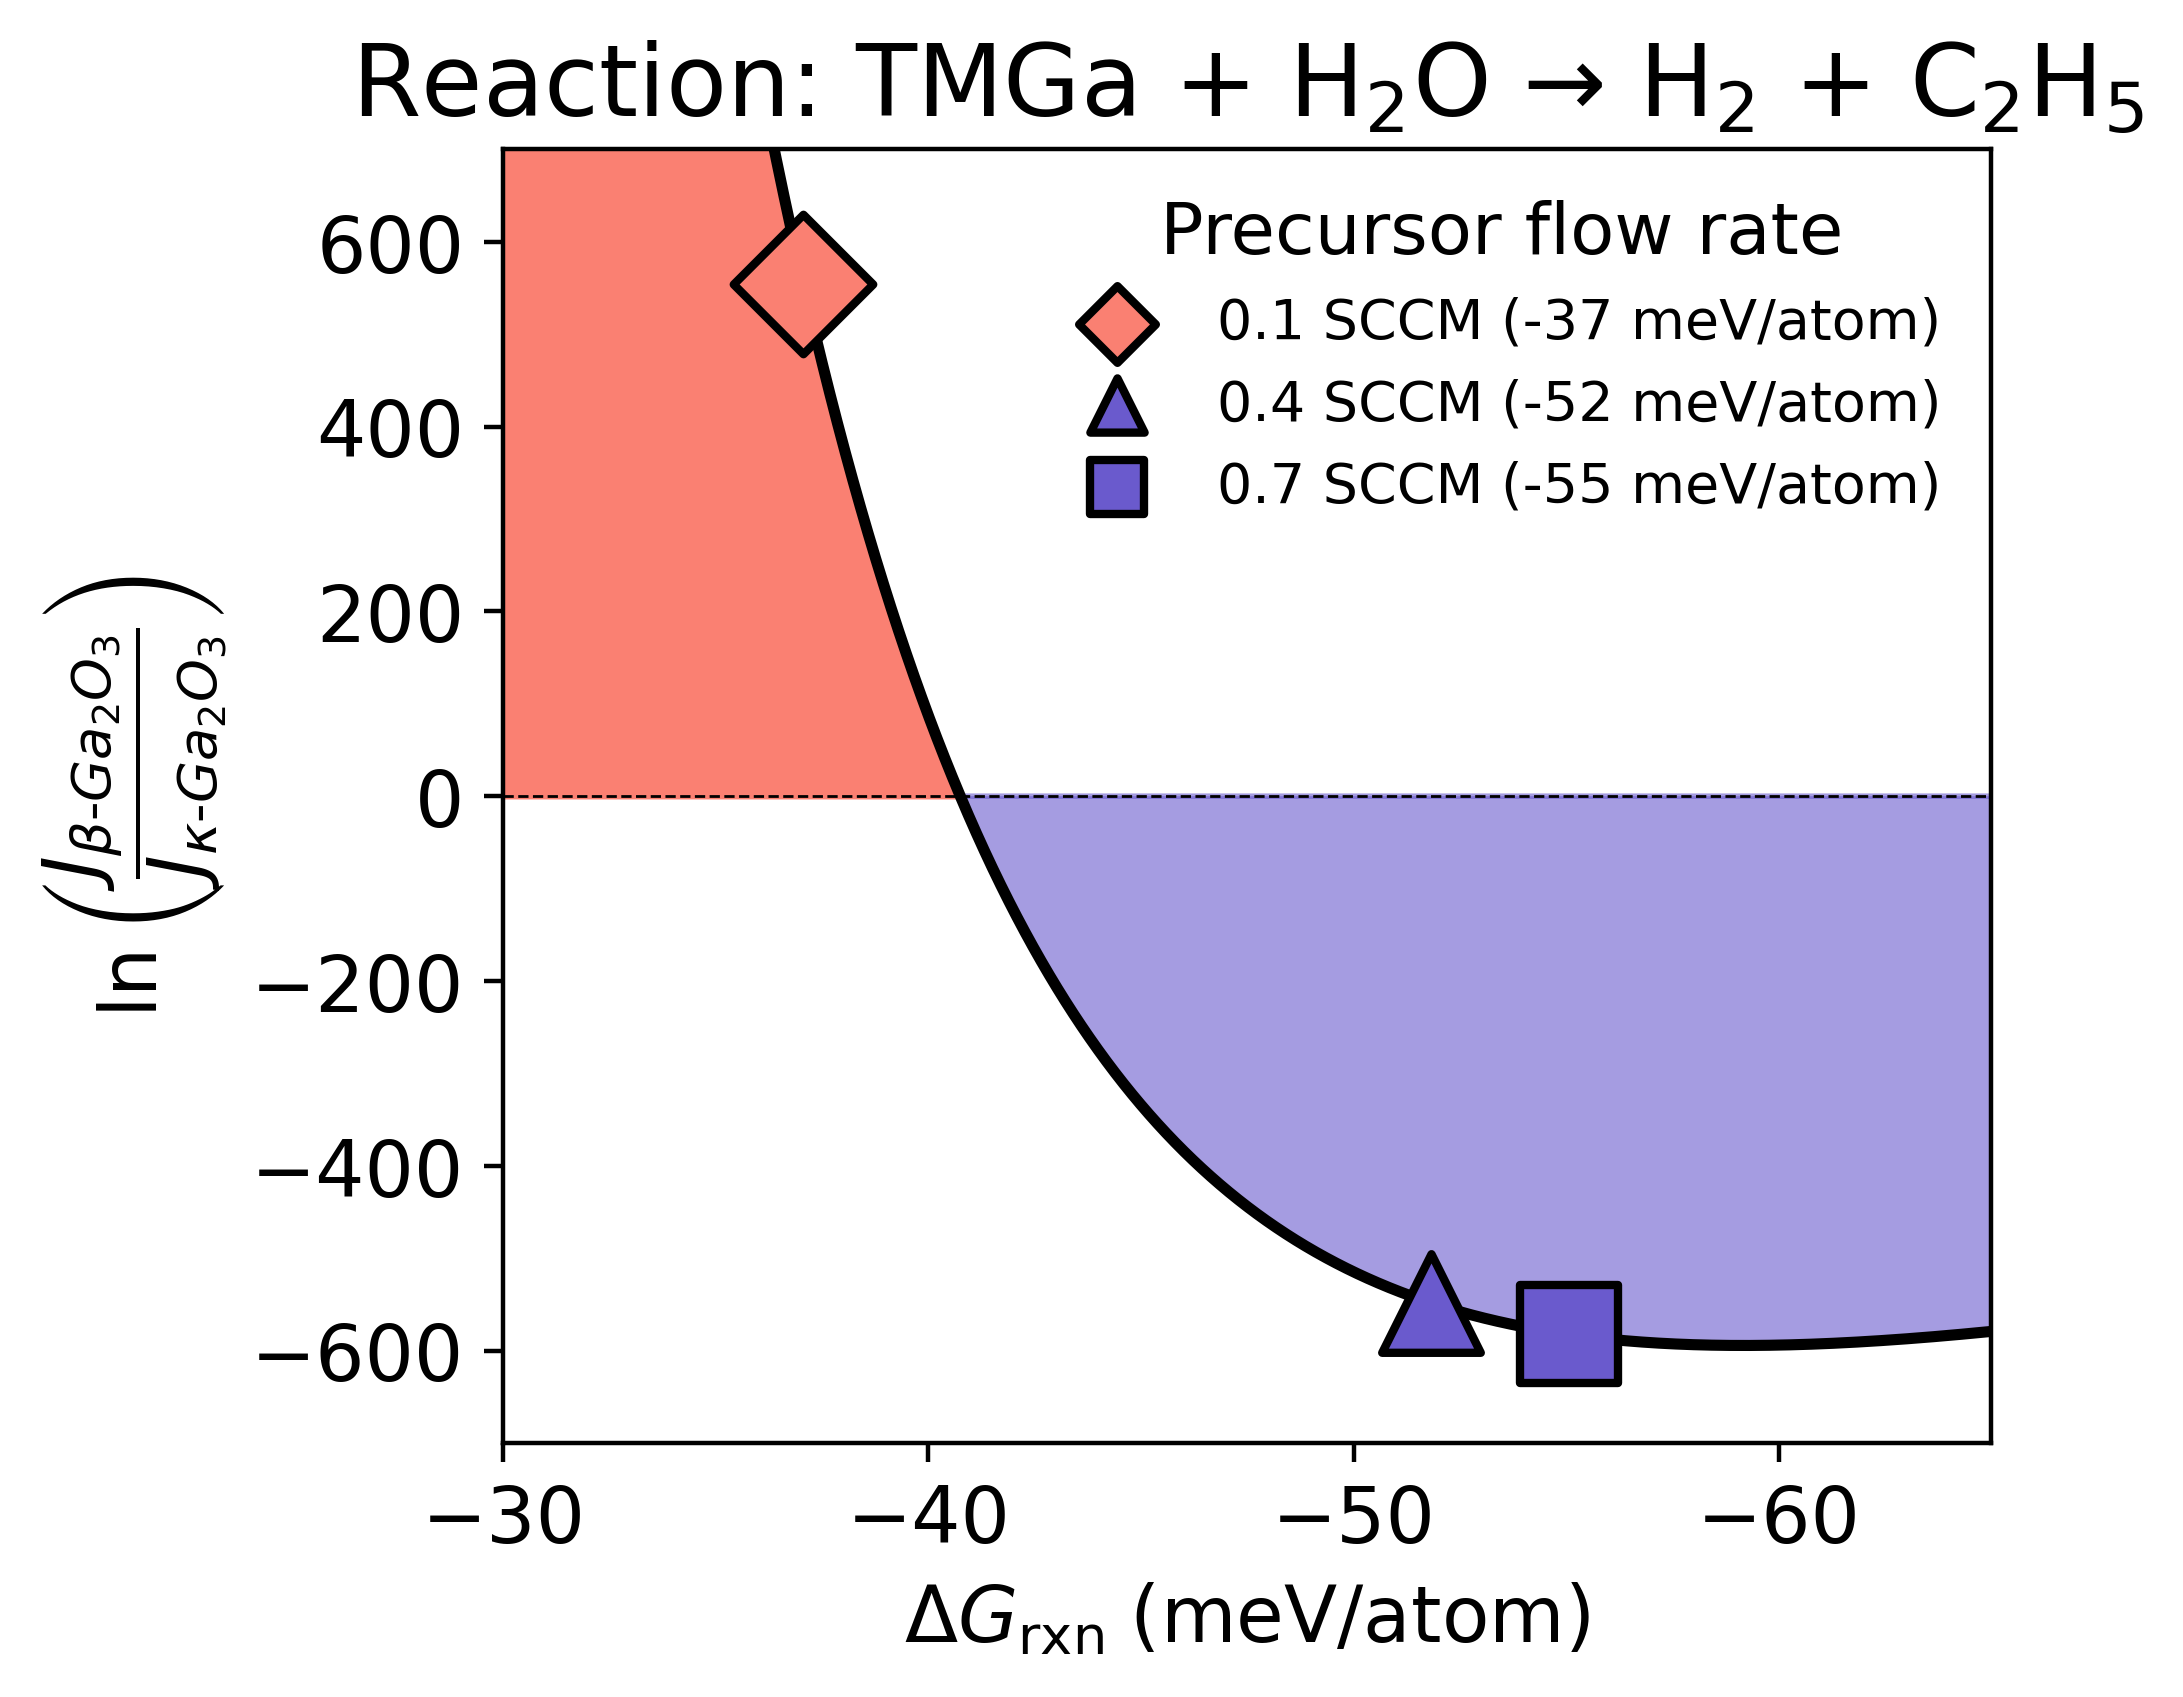

In [26]:
from matplotlib.colors import to_rgb

delta_g_rxn = np.arange(-300, 10, 0.01)

plt.figure(figsize=(4.8,4.2),dpi=400)

plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
ymin, ymax = -700,700
lnJ_on = np.log(nucleation_rate(
    e_surface + inter_e_a_Ga2O3 - e_surface_recon, density_e_a_ga2o3,
    b_surface + inter_b_a_Ga2O3 - b_surface_recon, density_b_a_ga2o3,
    delta_g_rxn,
    strain_b_e_a_ga2o3 + vib_E_diff_e_b,
    T
))
s=315
plt.title("Reaction: TMGa + H$_2$O → H$_2$ + C$_2$H$_5$",fontsize=18)


markers = ['o', 's', '^', 'D']   # Case 1~4
labels  = ["2 SCCM (-61 meV/atom)",
           "0.7 SCCM (-55 meV/atom)",
           "0.4 SCCM (-52 meV/atom)",
           "0.1 SCCM (-37 meV/atom)"]
# labels = cases
colors  = ['slateblue', 'slateblue', 'slateblue', 'salmon']

for dG, lJ, mk, lab, col in zip(delta_G[::-1], ln_J[::-1], markers[::-1], labels[::-1], colors[::-1]):
    plt.scatter(
        dG, lJ,
        s=s,
        edgecolors='k',
        linewidths=1.5,
        zorder=3,
        marker=mk,
        color=col,
        alpha=1,
        label=lab
    )

plt.legend(frameon=False, fontsize=ls-2, markerscale=0.55,title="Precursor flow rate",title_fontsize=ls+1)


lnJ_on_clipped = np.clip(lnJ_on, ymin, ymax)

plt.fill_between(delta_g_rxn, 0, lnJ_on_clipped, where=(lnJ_on_clipped < 0), 
                  color="slateblue", interpolate=True,alpha=0.6,zorder=1)

plt.fill_between(delta_g_rxn, 0, lnJ_on_clipped, where=(lnJ_on_clipped >=0), 
                  color="salmon", interpolate=True,zorder=1)

mask_finite = np.isfinite(lnJ_on)
plt.plot(delta_g_rxn[mask_finite], lnJ_on[mask_finite], color="black", linewidth=lw,zorder=2)

plt.ylabel(r"$\ln \left(\dfrac{J_{\beta\text{-}Ga_{2}O_{3}}}{J_{\kappa\text{-}Ga_{2}O_{3}}}\right)$", fontsize=ls+2)
plt.xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV}/\mathrm{atom})$", fontsize=ls+2)
plt.ylim(ymin,ymax)
plt.xlim(-30,-65)
plt.tick_params(labelsize=ls+2)